Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=129043497037424 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=129,137,667 params_trainable=129,137,667


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,No log,0.888338,0.633333,0.630913,0.669098,0.633333,0.173292,51.987544
2,No log,0.594361,0.776667,0.776668,0.778716,0.776667,0.111006,33.301710
3,1.708800,0.397734,0.860000,0.859173,0.861681,0.860000,0.071577,21.473167
4,1.708800,0.302583,0.896667,0.896665,0.897242,0.896667,0.053454,16.036226
5,1.708800,0.261020,0.916667,0.916447,0.916720,0.916667,0.045983,13.794908
6,0.517500,0.247180,0.916667,0.916582,0.916871,0.916667,0.043846,13.153724
7,0.517500,0.238953,0.920000,0.919924,0.920066,0.920000,0.042652,12.795500
8,0.227000,0.236291,0.916667,0.916629,0.916684,0.916667,0.042165,12.649436


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=14.24s tok/s=0.0 ex/s=0.00 peak_mem=3.83GiB lr=2.81e-05
[EVALUATION_PERFORMANCE] tokens=81920 time=0.61s tok/s=134565.7 ex/s=1051.29
[EVALUATION_PERFORMANCE] accuracy=0.6333 cost=$0.01 accuracy_per_$=74.02
[OPTIMIZER] epoch_start=1.0 global_step=19 wrapped=AcceleratedOptimizer base=AdamW lr=2.8098591549295775e-05 id=129043497037424 hyperparams={'lr': 2.8098591549295775e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 2.8098591549295775e-05, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 3e-05}
[SCHEDULER]   scheduler_last_lr=[2.8098591549295775e-05]
[PARAMS] 

[EVALUATION_PERFORMANCE] tokens=81920 time=0.68s tok/s=120811.2 ex/s=943.84
[EVALUATION_PERFORMANCE] accuracy=0.9433 cost=$0.13 accuracy_per_$=7.27

### STATE-SPACES/MAMBA-130M-HF EVALUATION METRICS ###
{'epoch': 8.0,
 'eval_accuracy': 0.9433333333333334,
 'eval_f1_macro': 0.9431570608041197,
 'eval_loss': 0.21999913454055786,
 'eval_mse': 0.03760731928902683,
 'eval_precision_macro': 0.9433542647828362,
 'eval_recall_macro': 0.9433333333333334,
 'eval_runtime': 0.7545,
 'eval_samples_per_second': 397.616,
 'eval_sse': 11.28219578670805,
 'eval_steps_per_second': 6.627}


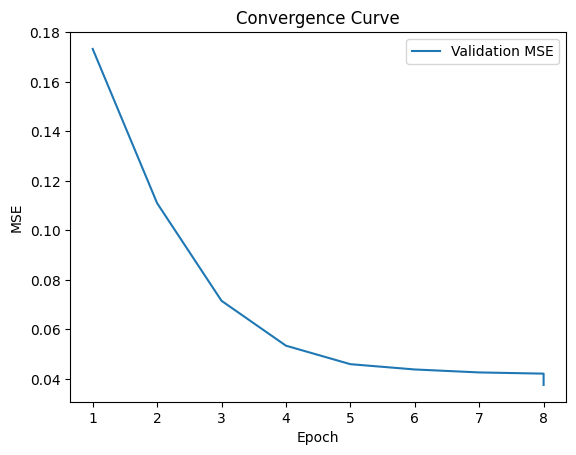

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    mamba_context = context.setup_pipeline(Mamba, require_translation = False)
    mamba_trainer = sentiment.train(mamba_context)

